# SMOTE Implementation
This notebook applies SMOTE (Synthetic Minority Oversampling Technique) on CNN-extracted features to address class imbalance, then trains a classifier on the balanced feature representation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB2

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

2026-03-04 16:59:45.423851: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 16:59:46.006234: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 16:59:57.081544: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORGANIZED_DIR = DATA_DIR / "organized"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models" / "smote"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 64
CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

## 1. Why SMOTE on Features?
SMOTE operates in feature space, not pixel space. Applying it directly to raw images generates unrealistic samples due to high dimensionality. Instead, we extract a compact feature vector from a pre-trained CNN and apply SMOTE there — the feature space is lower-dimensional and more semantically structured.

In [3]:
# Load training labels to inspect the class distribution before extraction
df_train = pd.read_csv(DATA_DIR / "train_split.csv")

class_counts = df_train["class_label"].value_counts().sort_index()
print("Training set class distribution:")
print(class_counts)

Training set class distribution:
class_label
AKIEC     229
BCC       360
BKL       769
DF         81
MEL       779
NV       4693
VASC       99
Name: count, dtype: int64


## 2. Build Feature Extractor
We reuse the EfficientNetB2 backbone (pre-trained on ImageNet) as a feature extractor. The Global Average Pooling output gives a 1408-dimensional feature vector per image — a compact representation capturing visual semantics.

In [4]:
base = EfficientNetB2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

feature_extractor = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D()
], name="feature_extractor")

print(f"Feature vector size: {feature_extractor.output_shape[1]}")

I0000 00:00:1772643617.223120  141823 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Feature vector size: 1408


## 3. Load Training Dataset
We load the organized training directory to pass through the feature extractor. Shuffling is disabled so labels align with extracted features.

In [5]:
train_dir = ORGANIZED_DIR / "train"

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

print(f"Total training batches: {len(train_ds)}")
print(f"Class names: {train_ds.class_names}")

Found 7010 files belonging to 7 classes.
Total training batches: 110
Class names: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


## 4. Extract Features
Run all training images through the extractor. This is the most time-consuming step in this notebook.

In [6]:
features_list = []
labels_list = []

for images, labels in train_ds:
    feats = feature_extractor(images, training=False)
    features_list.append(feats.numpy())
    labels_list.append(labels.numpy())

X = np.vstack(features_list)
y = np.concatenate(labels_list)

print(f"Extracted features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

2026-03-04 17:00:33.883787: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Extracted features shape: (7010, 1408)
Labels shape: (7010,)


2026-03-04 17:01:05.720562: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("Class distribution in extracted features:")
for idx, cls in enumerate(CLASS_NAMES):
    count = (y == idx).sum()
    print(f"  {cls}: {count}")

Class distribution in extracted features:
  AKIEC: 229
  BCC: 360
  BKL: 769
  DF: 81
  MEL: 779
  NV: 4693
  VASC: 99


## 5. Apply SMOTE
SMOTE synthesizes new minority samples by interpolating between existing feature vectors. We use k_neighbors=5 (default). For very small minority classes (DF: 167, VASC: 177), SMOTE can work since neighbors exist in a 1408-D space.

In [8]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE: {X.shape[0]} samples")
print(f"After SMOTE:  {X_resampled.shape[0]} samples")

Before SMOTE: 7010 samples
After SMOTE:  32851 samples


In [9]:
print("Class distribution after SMOTE:")
for idx, cls in enumerate(CLASS_NAMES):
    count = (y_resampled == idx).sum()
    print(f"  {cls}: {count}")

Class distribution after SMOTE:
  AKIEC: 4693
  BCC: 4693
  BKL: 4693
  DF: 4693
  MEL: 4693
  NV: 4693
  VASC: 4693


## 6. Visualize Feature Space Before / After SMOTE
We reduce to 2D with PCA to compare the feature distribution before and after oversampling.

In [10]:
from sklearn.decomposition import PCA

# Fit PCA on original features, project both
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
X_res_pca = pca.transform(X_resampled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

PCA explained variance ratio: [0.15003733 0.09781759]


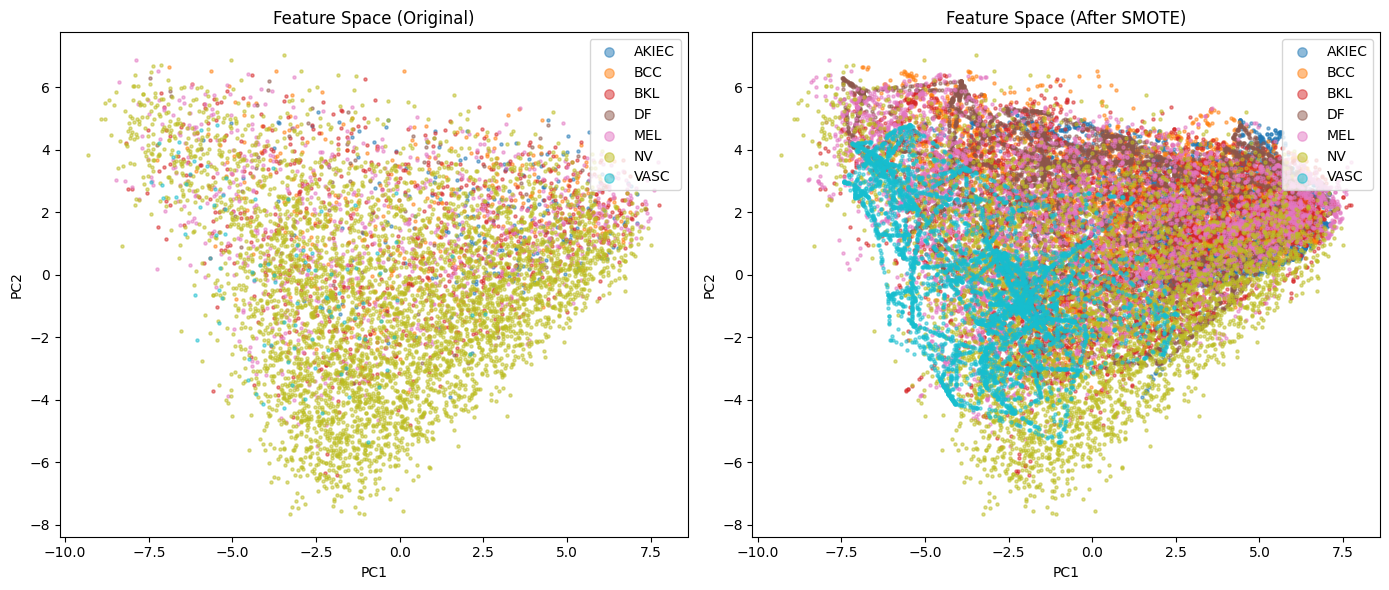

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(CLASS_NAMES)))

for idx, (cls, c) in enumerate(zip(CLASS_NAMES, colors)):
    mask = y == idx
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, color=c, label=cls, alpha=0.5)

axes[0].set_title("Feature Space (Original)")
axes[0].legend(markerscale=3, loc='upper right')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

for idx, (cls, c) in enumerate(zip(CLASS_NAMES, colors)):
    mask = y_resampled == idx
    axes[1].scatter(X_res_pca[mask, 0], X_res_pca[mask, 1], s=5, color=c, label=cls, alpha=0.5)

axes[1].set_title("Feature Space (After SMOTE)")
axes[1].legend(markerscale=3, loc='upper right')
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "smote_pca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Train MLP Head on SMOTE Features
Since SMOTE operates in feature space, we train a lightweight MLP head on the balanced features. This is not end-to-end training but tests whether SMOTE-balanced features improve minority class classification.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled,
    test_size=0.15,
    stratify=y_resampled,
    random_state=42
)

print(f"SMOTE train: {len(X_train)}, val: {len(X_val)}")

SMOTE train: 27923, val: 4928


In [13]:
def build_mlp_head(input_dim, num_classes=8):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax")
    ], name="smote_mlp")
    return model

mlp = build_mlp_head(X_resampled.shape[1])
mlp.summary()

Model: "smote_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 854,792 (3.26 MB)

 Trainable params: 854,792 (3.26 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'smote_mlp_best.keras'),
        monitor='val_accuracy', save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

history = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=callbacks
)

Epoch 1/50


2026-03-04 17:02:44.322739: I external/local_xla/xla/service/service.cc:163] XLA service 0x716ddc004ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 17:02:44.322777: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-03-04 17:02:44.383374: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 17:02:45.311468: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1004', 64 bytes spill stores, 64 bytes spill loads

2026-03-04 17:02:45.461153: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 1224 bytes spill stores, 1176 by

 63/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4666 - loss: 1.3706

I0000 00:00:1772643766.992330  142037 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5316 - loss: 1.2109

2026-03-04 17:02:47.863658: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 12 bytes spill stores, 12 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5339 - loss: 1.2054

2026-03-04 17:02:49.994281: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_42', 12 bytes spill stores, 12 bytes spill loads



110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6552 - loss: 0.9071 - val_accuracy: 0.7904 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8274 - loss: 0.4732 - val_accuracy: 0.8600 - val_loss: 0.3832 - learning_rate: 0.0010
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8715 - loss: 0.3513 - val_accuracy: 0.9042 - val_loss: 0.2715 - learning_rate: 0.0010
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9068 - loss: 0.2620 - val_accuracy: 0.9044 - val_loss: 0.2673 - learning_rate: 0.0010
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9264 - loss: 0.2128 - val_accuracy: 0.9093 - val_loss: 0.2453 - learning_rate: 0.0010
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9330 - loss: 0.1924 - val_accuracy: 0.9434 - val_loss: 0.1568 - learning_rate: 0.0010
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9510 - loss: 0.1396 - val_accura

## 8. Training Curves

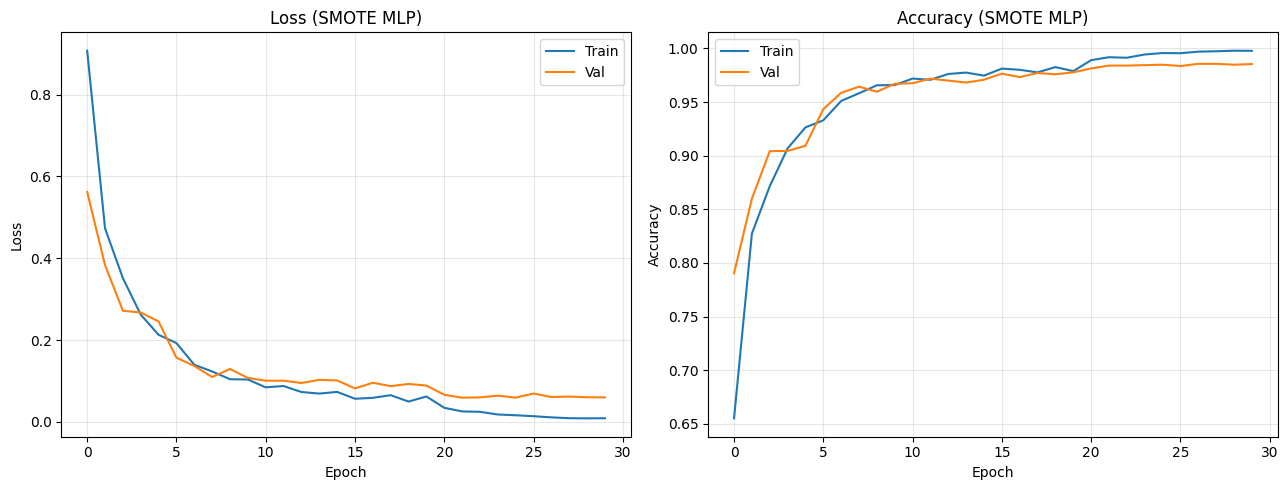

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title("Loss (SMOTE MLP)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title("Accuracy (SMOTE MLP)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "smote_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluate on Test Set

In [16]:
# Extract test features using the same backbone
test_dir = ORGANIZED_DIR / "test"

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

Found 1503 files belonging to 7 classes.


In [17]:
test_features = []
test_labels = []

for images, labels in test_ds:
    feats = feature_extractor(images, training=False)
    test_features.append(feats.numpy())
    test_labels.append(labels.numpy())

X_test = np.vstack(test_features)
y_test = np.concatenate(test_labels)

print(f"Test features: {X_test.shape}")

Test features: (1503, 1408)


2026-03-04 17:03:23.936741: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
y_pred = np.argmax(mlp.predict(X_test, batch_size=256), axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

1/6 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step

2026-03-04 17:03:24.788763: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9', 60 bytes spill stores, 60 bytes spill loads

2026-03-04 17:03:24.889558: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9', 1616 bytes spill stores, 1212 bytes spill loads



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step
              precision    recall  f1-score   support

       AKIEC       0.49      0.37      0.42        49
         BCC       0.58      0.55      0.56        77
         BKL       0.58      0.53      0.56       165
          DF       0.35      0.35      0.35        17
         MEL       0.49      0.40      0.44       167
          NV       0.88      0.92      0.90      1006
        VASC       0.67      0.82      0.73        22

    accuracy                           0.78      1503
   macro avg       0.58      0.56      0.57      1503
weighted avg       0.76      0.78      0.77      1503



## 10. Confusion Matrix

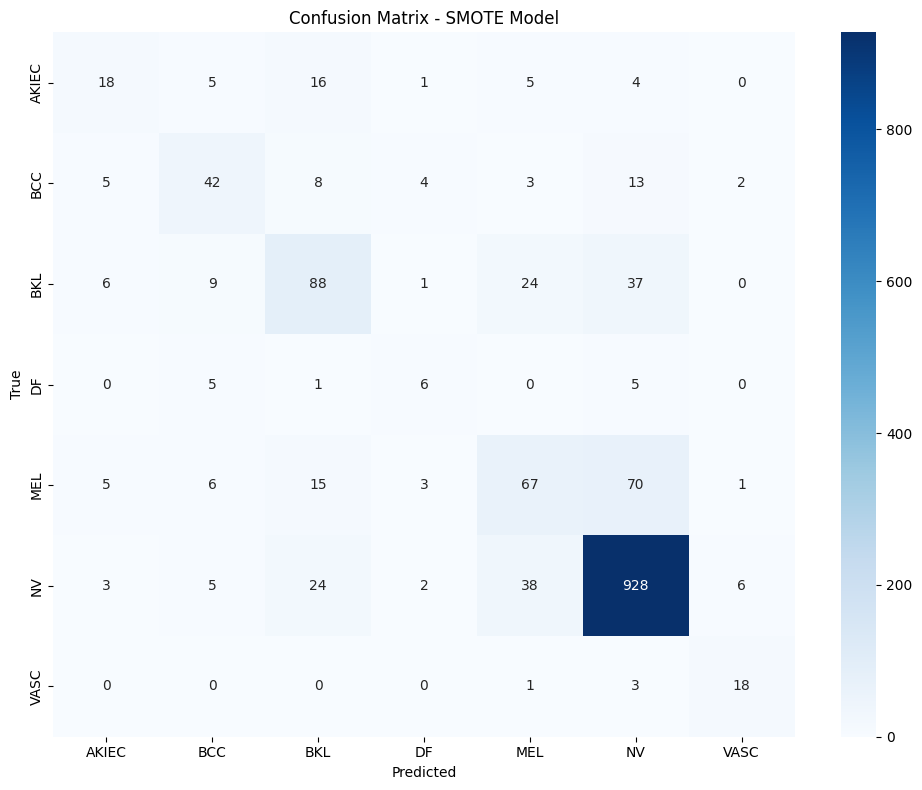

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SMOTE Model')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "smote_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. SMOTE Limitations for Image Data
Feature-space SMOTE improves minority class recall relative to the unbalanced baseline because it gives the classifier more balanced training signal. However:
- Interpolated feature vectors may not correspond to any real image, reducing generalizability
- The backbone is frozen, so the classifier head cannot learn from raw pixel patterns
- For DF and VASC (very few samples), even SMOTE interpolations are limited by the diversity of original samples

In [20]:
from sklearn.metrics import f1_score, accuracy_score

smote_summary = {
    "model": "SMOTE + MLP on EfficientNetB2 features",
    "feature_dim": int(X.shape[1]),
    "samples_before_smote": int(X.shape[0]),
    "samples_after_smote": int(X_resampled.shape[0]),
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average='macro'))
}

with open(RESULTS_DIR / "smote_summary.json", "w") as f:
    json.dump(smote_summary, f, indent=2)

print("SMOTE summary saved.")
print(f"Test accuracy: {smote_summary['test_accuracy']:.4f}")
print(f"Macro F1:      {smote_summary['macro_f1']:.4f}")

SMOTE summary saved.
Test accuracy: 0.7764
Macro F1:      0.5661
